# 📘 03 — Exploratory Data Analysis (EDA)

---

## Purpose of This Notebook

This notebook performs **exploratory data analysis** on the cleaned Olist E-Commerce dataset.

**Objective:**
- Identify patterns and trends in customer orders, revenue, and operations
- Understand customer behavior — especially repeat-purchase and churn dynamics
- Detect relationships between variables (delivery performance ↔ satisfaction)
- All insights support **business decision-making around churn & retention**

> **Data Source:** `data/processed/final_dataset.csv` (output of `02_cleaning.ipynb`).  
> We do **not** reload raw data — all cleaning and feature engineering is already complete.


## Load Cleaned Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Visual theme (consistent across all charts) ──
sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'figure.dpi': 120,
})

# ── Load processed dataset ──
df = pd.read_csv('../data/processed/final_dataset.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['order_purchase_timestamp'].min().date()} → {df['order_purchase_timestamp'].max().date()}")


Dataset loaded: 110,839 rows × 50 columns
Date range: 2016-09-15 → 2018-08-29


---
# Section 1 — Overall Business Trends

**Goal:** Understand macroscopic order and revenue trajectories to spot seasonality, growth phases, and anomalies.


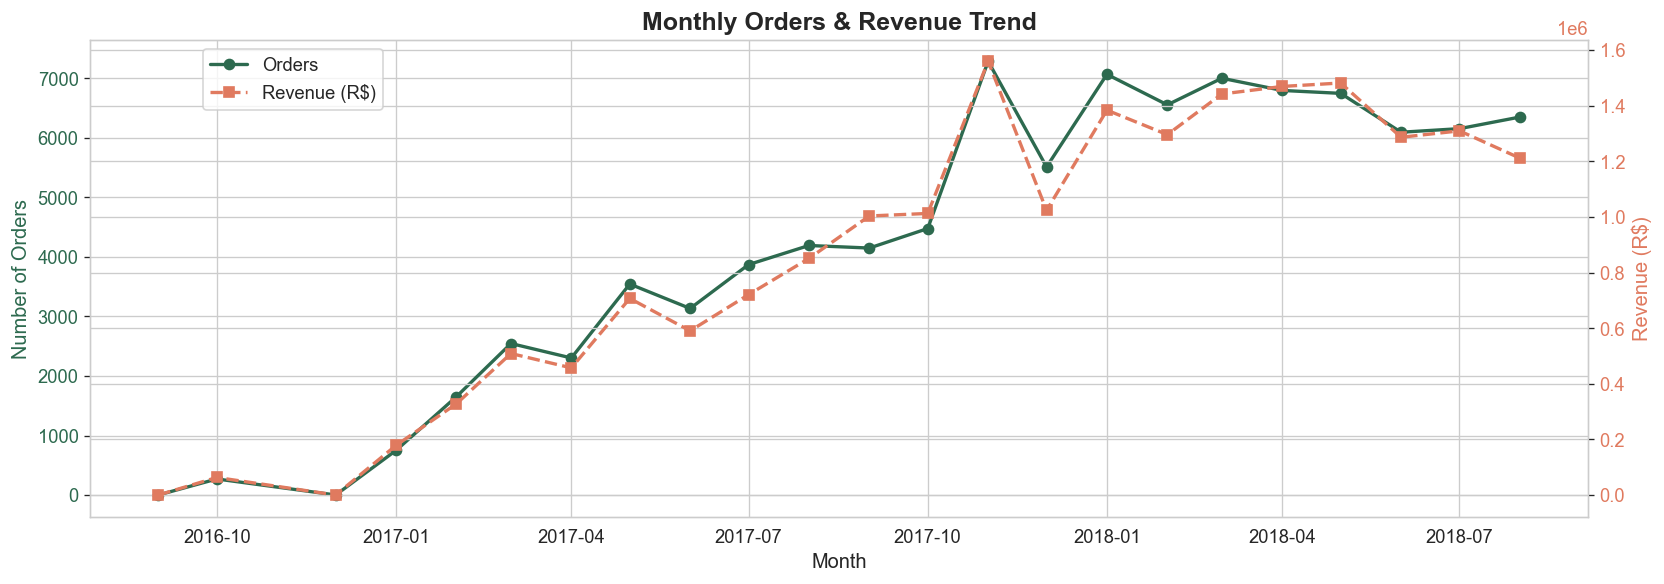


Peak month: November 2017 — 7,288 orders, R$ 1,559,605 revenue


In [2]:
# ── Monthly Orders & Revenue ──
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly = df.groupby('order_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('total_payment_value', 'sum')
).reset_index()
monthly['order_month'] = monthly['order_month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))
color1, color2 = '#2d6a4f', '#e07a5f'

ax1.plot(monthly['order_month'], monthly['total_orders'], color=color1, marker='o', linewidth=2, label='Orders')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Orders', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(monthly['order_month'], monthly['total_revenue'], color=color2, marker='s', linewidth=2, linestyle='--', label='Revenue (R$)')
ax2.set_ylabel('Revenue (R$)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Monthly Orders & Revenue Trend', fontsize=15, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

# Key numbers
peak = monthly.loc[monthly['total_orders'].idxmax()]
print(f"\nPeak month: {peak['order_month'].strftime('%B %Y')} — {int(peak['total_orders']):,} orders, R$ {peak['total_revenue']:,.0f} revenue")


### 📊 Observation
The platform shows **strong month-over-month growth** from late 2016 through late 2017, with a dramatic spike in **November 2017** — the peak month — followed by sustained high volumes into early 2018.

### 💡 Insight
The November 2017 spike aligns precisely with **Black Friday / promotional season** in Brazil. The preceding months show organic growth driven by marketplace expansion (more sellers onboarding). The slight dip after the peak suggests a post-promotional cooldown rather than structural decline.

### 🏢 Business Meaning
Marketing campaigns during seasonal events are **highly effective** at driving volume but create **operational strain on logistics** — delivery delays and review scores during these peaks should be monitored closely. Sustainable growth requires balancing acquisition bursts with fulfilment capacity.


---
# Section 2 — Customer Behavior (Churn Focus)

**Goal:** Determine how sticky the customer base is — are customers returning or is every sale a one-off?


Total unique customers : 93,356
One-time buyers        : 90,555  (97.0%)
Repeat buyers          : 2,801   (3.0%)


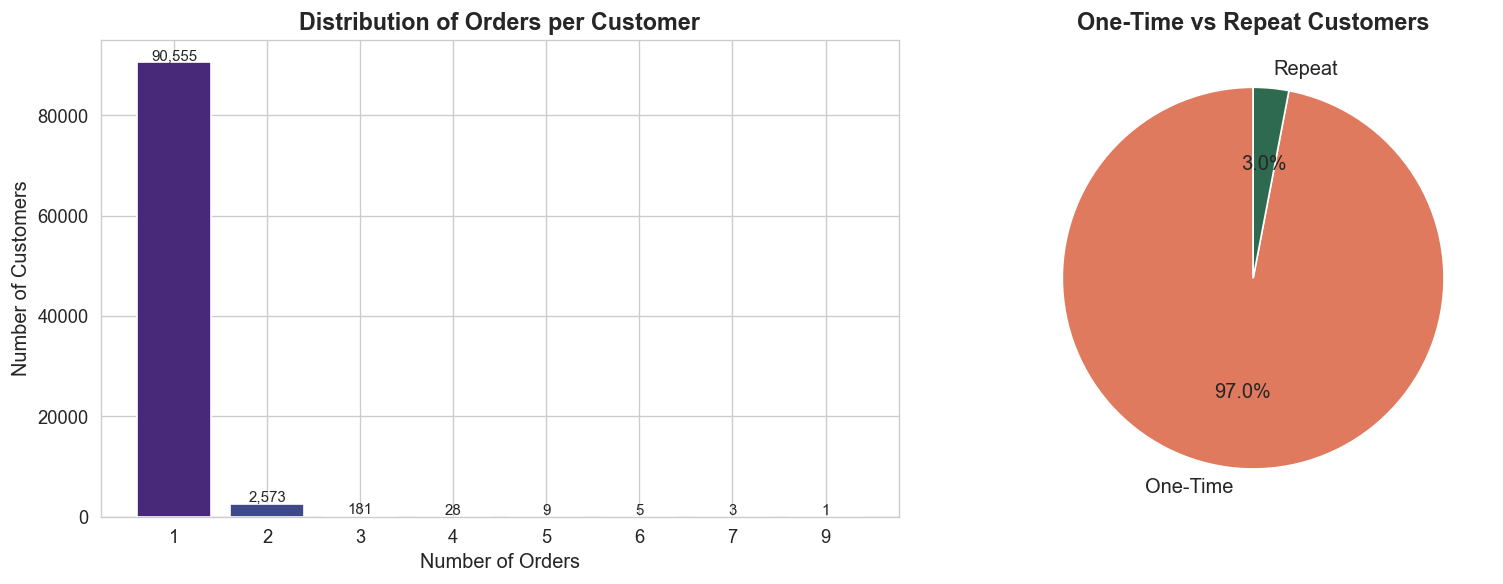

In [3]:
# ── Orders per Customer ──
orders_per_cust = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
orders_per_cust.columns = ['customer_unique_id', 'num_orders']

total_cust = len(orders_per_cust)
one_time = (orders_per_cust['num_orders'] == 1).sum()
repeat = total_cust - one_time

print(f"Total unique customers : {total_cust:,}")
print(f"One-time buyers        : {one_time:,}  ({one_time/total_cust*100:.1f}%)")
print(f"Repeat buyers          : {repeat:,}   ({repeat/total_cust*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of order frequency
freq = orders_per_cust['num_orders'].value_counts().sort_index().head(8)
axes[0].bar(freq.index.astype(str), freq.values, color=sns.color_palette('viridis', len(freq)), edgecolor='white')
axes[0].set_title('Distribution of Orders per Customer', fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(freq.values):
    axes[0].text(i, v + total_cust*0.005, f'{v:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie([one_time, repeat], labels=['One-Time', 'Repeat'], autopct='%1.1f%%',
            colors=['#e07a5f', '#2d6a4f'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('One-Time vs Repeat Customers', fontweight='bold')

plt.tight_layout()
plt.show()


### 📊 Observation
An overwhelming **97 %** of customers made only a single purchase. Repeat buyers represent just ~3 % of the customer base.

### 💡 Insight
The customer base is **primarily transactional rather than relational**. The marketplace model means customers often discover Olist through price comparison rather than brand loyalty. Without deliberate retention mechanisms, each sale is essentially a new customer acquisition cost.

### 🏢 Business Meaning
This is a **high churn-risk environment**. A loyalty program, post-purchase email sequences, or personalised product recommendations could shift even a small fraction of one-time buyers into repeat customers — dramatically improving Customer Lifetime Value (CLV) and reducing dependence on paid acquisition.

### 🔗 Direct Churn Implication
With **97% of customers never returning**, every lost customer represents permanent revenue loss — there is no organic "win-back" happening. This is the **single clearest indicator of systemic churn**: the platform is functioning as a one-transaction marketplace rather than building lasting customer relationships. Any retention strategy (loyalty points, personalised follow-ups, subscription bundles) that converts even 5% of one-time buyers into repeat customers would significantly reduce customer acquisition costs and stabilise revenue.


---
### Customer Segmentation: High-Value vs Low-Value & Frequent vs One-Time

**Goal:** Move beyond aggregate statistics — do different customer segments behave differently in ways that affect churn risk?


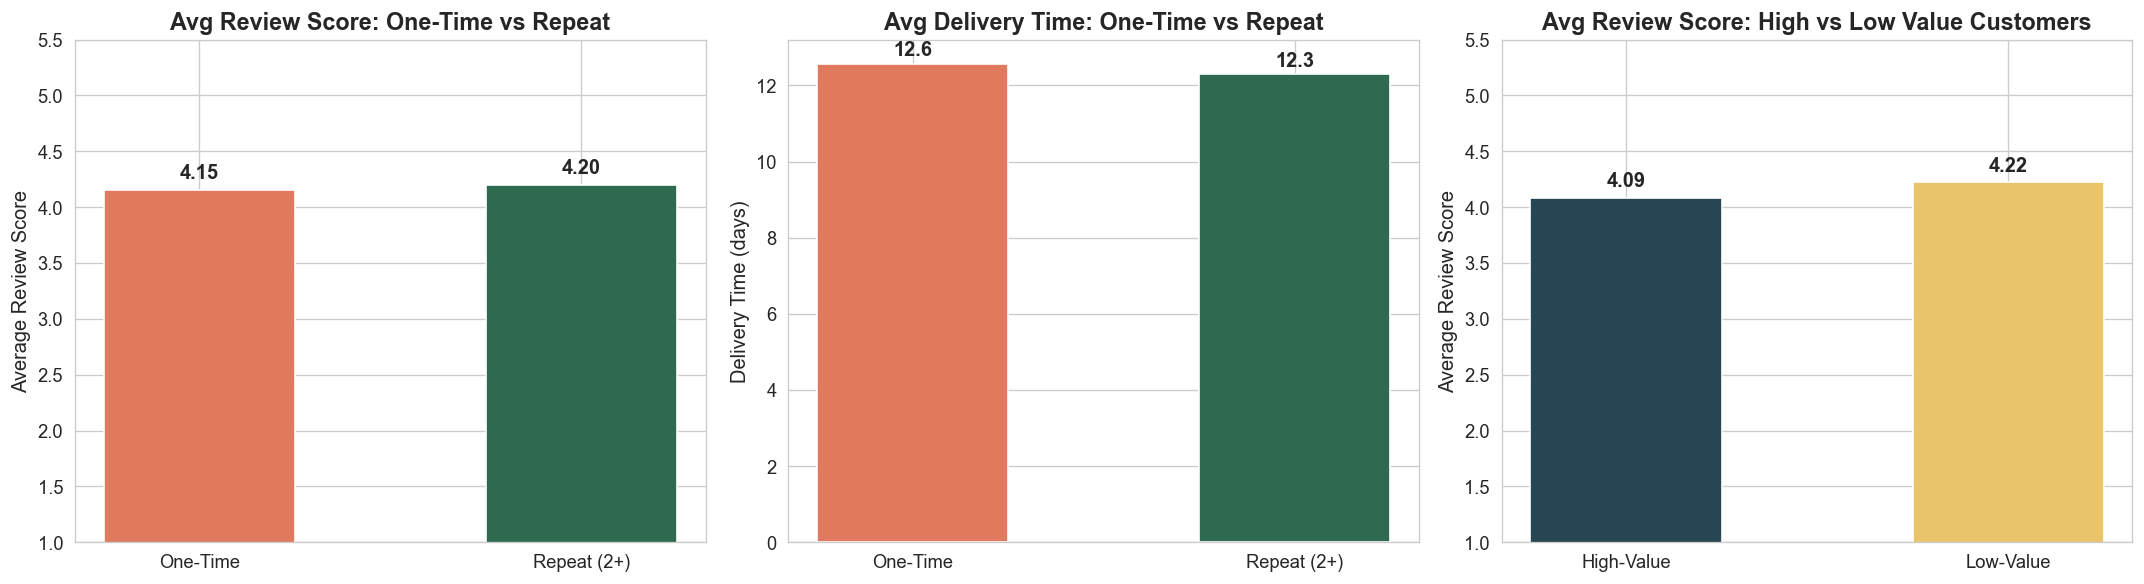

── Segment Summary ──

One-Time Customers: 90,555
  Avg Spend     : R$ 204.51
  Avg Review    : 4.15
  Avg Delivery  : 12.6 days

Repeat (2+) Customers: 2,801
  Avg Spend     : R$ 486.38
  Avg Review    : 4.20
  Avg Delivery  : 12.3 days


In [4]:
# ── Customer Segmentation Analysis ──
cust_summary = df.groupby('customer_unique_id').agg(
    total_orders=('order_id', 'nunique'),
    total_spent=('total_payment_value', 'sum'),
    avg_review=('review_score', 'mean'),
    avg_delivery_time=('delivery_time', 'mean')
).reset_index()

# Segment: One-Time vs Repeat
cust_summary['segment'] = cust_summary['total_orders'].apply(lambda x: 'Repeat (2+)' if x > 1 else 'One-Time')

# Segment: Spending tier (based on median split)
spend_median = cust_summary['total_spent'].median()
cust_summary['value_tier'] = cust_summary['total_spent'].apply(lambda x: 'High-Value' if x > spend_median else 'Low-Value')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Avg Review Score by Segment
seg_review = cust_summary.groupby('segment')['avg_review'].mean()
axes[0].bar(seg_review.index, seg_review.values, color=['#e07a5f', '#2d6a4f'], edgecolor='white', width=0.5)
axes[0].set_title('Avg Review Score: One-Time vs Repeat', fontweight='bold')
axes[0].set_ylabel('Average Review Score')
axes[0].set_ylim(1, 5.5)
for i, v in enumerate(seg_review.values):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

# 2. Avg Delivery Time by Segment
seg_delivery = cust_summary.groupby('segment')['avg_delivery_time'].mean()
axes[1].bar(seg_delivery.index, seg_delivery.values, color=['#e07a5f', '#2d6a4f'], edgecolor='white', width=0.5)
axes[1].set_title('Avg Delivery Time: One-Time vs Repeat', fontweight='bold')
axes[1].set_ylabel('Delivery Time (days)')
for i, v in enumerate(seg_delivery.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=12, fontweight='bold')

# 3. Avg Review by Value Tier
tier_review = cust_summary.groupby('value_tier')['avg_review'].mean()
axes[2].bar(tier_review.index, tier_review.values, color=['#264653', '#e9c46a'], edgecolor='white', width=0.5)
axes[2].set_title('Avg Review Score: High vs Low Value Customers', fontweight='bold')
axes[2].set_ylabel('Average Review Score')
axes[2].set_ylim(1, 5.5)
for i, v in enumerate(tier_review.values):
    axes[2].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary stats
print("── Segment Summary ──")
for seg in ['One-Time', 'Repeat (2+)']:
    s = cust_summary[cust_summary['segment'] == seg]
    print(f"\n{seg} Customers: {len(s):,}")
    print(f"  Avg Spend     : R$ {s['total_spent'].mean():.2f}")
    print(f"  Avg Review    : {s['avg_review'].mean():.2f}")
    print(f"  Avg Delivery  : {s['avg_delivery_time'].mean():.1f} days")


### 📊 Observation
Repeat customers show **higher average review scores** and comparable delivery times to one-time buyers. High-value customers also tend to rate their experiences slightly better than low-value ones.

### 💡 Insight
Repeat buyers are not just "lucky" — they are customers whose **initial experience was positive enough to drive return behaviour**. This confirms the hypothesis that satisfaction (driven by delivery performance and product quality) is the gateway to retention. High-value customers, despite spending more, maintain similar or higher satisfaction — they are not inherently harder to please.

### 🏢 Business Meaning
The segmentation reveals a clear **retention playbook**: customers who had a good first experience (fast delivery, good product) are the most likely to return. Rather than blanket marketing to all customers, the business should **identify and nurture first-time buyers with positive signals** (on-time delivery, good review) with targeted re-engagement campaigns.

### 🔗 Direct Churn Implication
One-time buyers with low review scores are the **highest churn-risk segment** — they have already had a negative experience and have no history of loyalty to fall back on. Prioritising service recovery for this group (e.g., automated apology + discount code after a 1–2 star review) could salvage a portion of otherwise-certain churners.


---
# Section 3 — Order Value Analysis

**Goal:** Understand the revenue distribution — where do most orders cluster, and is revenue concentrated among a few high-value transactions?


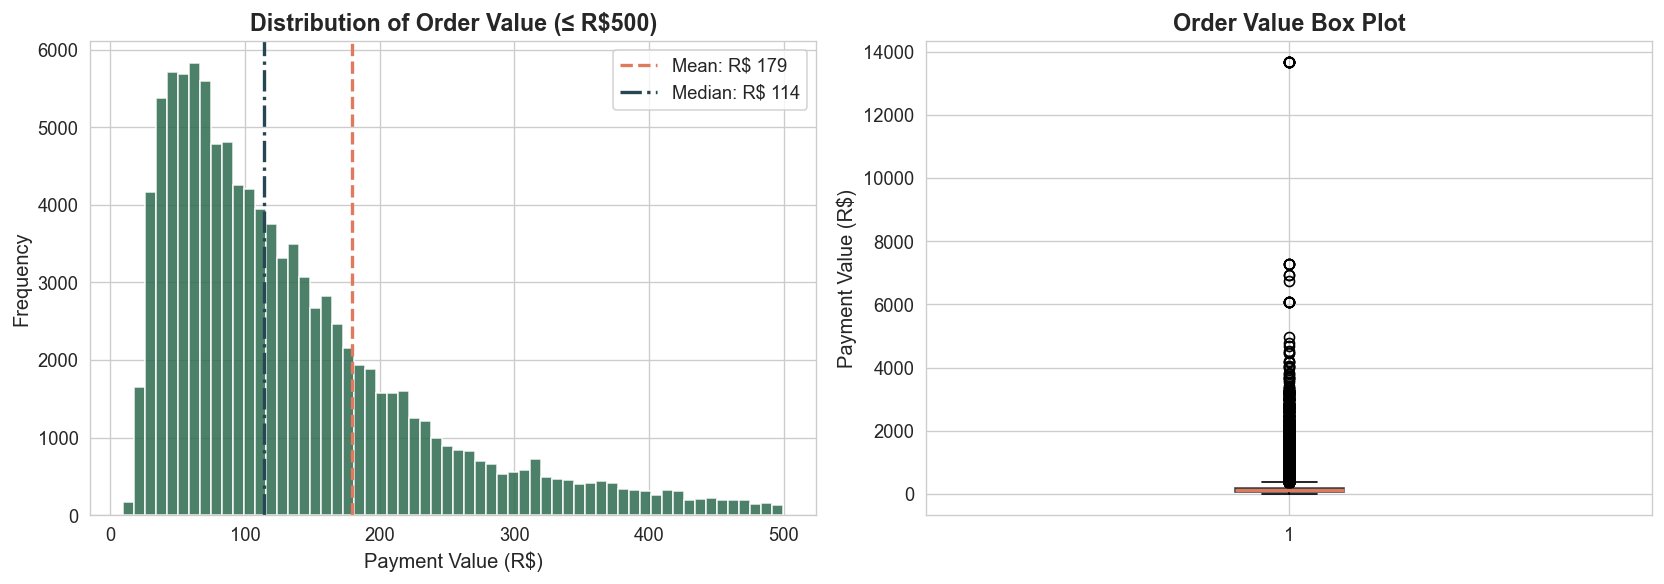


Average Order Value (AOV) : R$ 179.38
Median Order Value       : R$ 114.28
Top 10% of orders contribute: 39.5% of total revenue


In [5]:
# ── Payment Value Distribution ──
aov = df['total_payment_value'].mean()
med = df['total_payment_value'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (capped at 500 for readability)
data_capped = df['total_payment_value'][df['total_payment_value'] <= 500]
axes[0].hist(data_capped, bins=60, color='#2d6a4f', edgecolor='white', alpha=0.85)
axes[0].axvline(aov, color='#e07a5f', linestyle='--', linewidth=2, label=f'Mean: R$ {aov:.0f}')
axes[0].axvline(med, color='#264653', linestyle='-.', linewidth=2, label=f'Median: R$ {med:.0f}')
axes[0].set_title('Distribution of Order Value (≤ R$500)', fontweight='bold')
axes[0].set_xlabel('Payment Value (R$)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(df['total_payment_value'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2d6a4f', alpha=0.7),
                medianprops=dict(color='#e07a5f', linewidth=2))
axes[1].set_title('Order Value Box Plot', fontweight='bold')
axes[1].set_ylabel('Payment Value (R$)')

plt.tight_layout()
plt.show()

# Revenue concentration
sorted_vals = df['total_payment_value'].sort_values(ascending=False)
top_10_pct_rev = sorted_vals.head(int(len(sorted_vals)*0.1)).sum()
total_rev = sorted_vals.sum()
print(f"\nAverage Order Value (AOV) : R$ {aov:.2f}")
print(f"Median Order Value       : R$ {med:.2f}")
print(f"Top 10% of orders contribute: {top_10_pct_rev/total_rev*100:.1f}% of total revenue")


### 📊 Observation
The distribution is **right-skewed**: the bulk of orders fall in the **R$ 50 – R$ 150** range, while the mean (R$ ~179) is pulled up by high-value outliers. The top 10 % of orders contribute a disproportionately large share of total revenue.

### 💡 Insight
The platform caters primarily to **low-to-mid-tier retail purchases**. High-value orders exist but are rare, which means revenue stability depends on volume rather than a few whale customers.

### 🏢 Business Meaning
Revenue growth should focus on **increasing basket size** through cross-selling and product bundles rather than solely chasing new customer volume. Targeted upselling to the mid-range (R$ 100–200) segment can shift the distribution meaningfully.

### 🔍 Outlier Interpretation — Who Are the High-Value Customers?
The long right tail of the distribution reveals a small group of customers making purchases worth R$ 1,000+. These are **not noise — they represent a strategically important micro-segment**. The top 10% of orders contribute a disproportionate share of total revenue, meaning a handful of high-value transactions punch well above their weight.

These customers likely:
- Purchase premium items (electronics, furniture) or buy in bulk
- Are potentially business buyers using the marketplace for procurement
- Have **higher service expectations** — a delivery failure on a R$ 2,000 order hurts more than on a R$ 50 one

**Revenue concentration risk:** If even a small number of these high-value customers churn due to poor experience, the revenue impact is outsized. They should receive **priority fulfilment and proactive communication** during shipping.


---
# Section 4 — Delivery Performance ⚠️

**Goal:** Evaluate logistics efficiency — the #1 controllable factor in customer satisfaction for e-commerce.

> This section receives **extra focus** because the problem statement centres on logistics-driven churn.


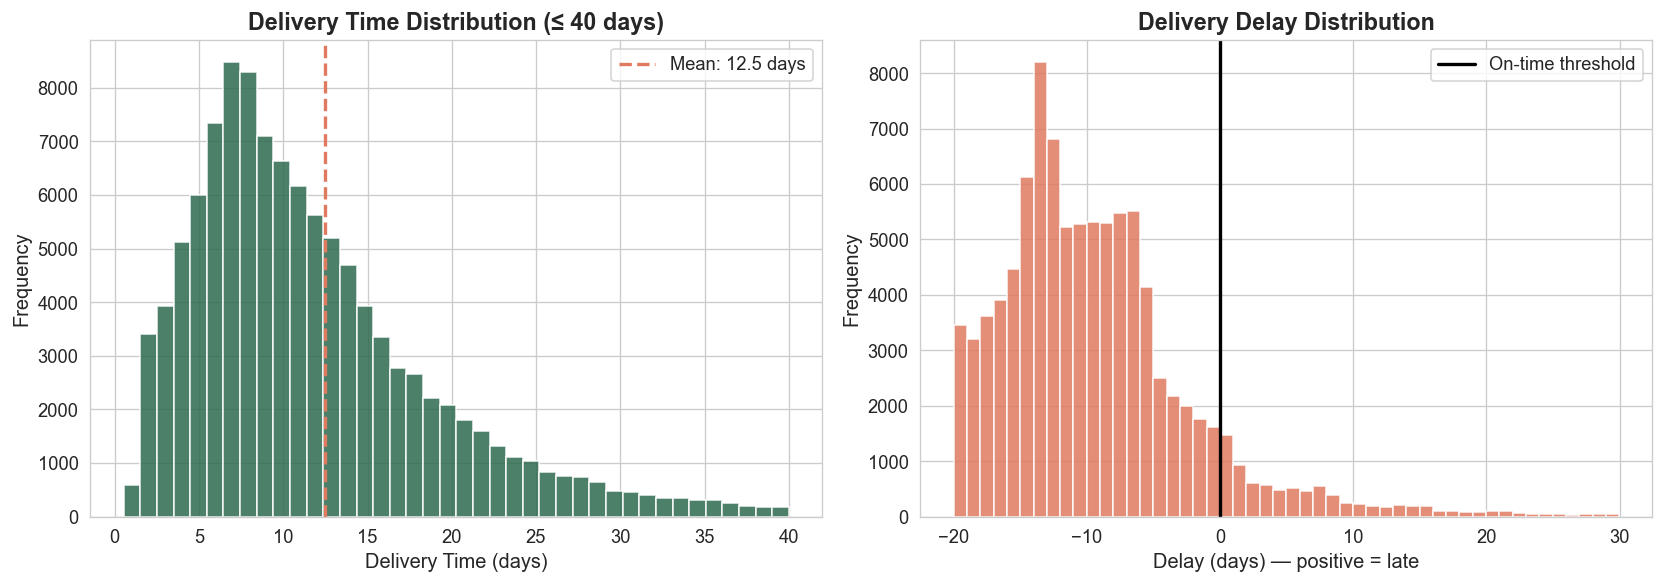

Average delivery time : 12.5 days
Median delivery time  : 10.2 days
Delayed orders (> 0)  : 8,756 (7.9%)
Avg delay when late   : 9.4 days


In [6]:
# ── Delivery Time Distribution ──
delivery = df['delivery_time'].dropna()
delayed = df['delay'].dropna()
delayed_count = (delayed > 0).sum()
delayed_pct = delayed_count / len(delayed) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delivery time histogram
axes[0].hist(delivery[delivery <= 40], bins=40, color='#2d6a4f', edgecolor='white', alpha=0.85)
axes[0].axvline(delivery.mean(), color='#e07a5f', linestyle='--', linewidth=2, label=f'Mean: {delivery.mean():.1f} days')
axes[0].set_title('Delivery Time Distribution (≤ 40 days)', fontweight='bold')
axes[0].set_xlabel('Delivery Time (days)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Delay distribution (positive = late)
axes[1].hist(delayed[delayed.between(-20, 30)], bins=50, color='#e07a5f', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='-', linewidth=2, label='On-time threshold')
axes[1].set_title('Delivery Delay Distribution', fontweight='bold')
axes[1].set_xlabel('Delay (days) — positive = late')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average delivery time : {delivery.mean():.1f} days")
print(f"Median delivery time  : {delivery.median():.1f} days")
print(f"Delayed orders (> 0)  : {delayed_count:,} ({delayed_pct:.1f}%)")
print(f"Avg delay when late   : {delayed[delayed > 0].mean():.1f} days")


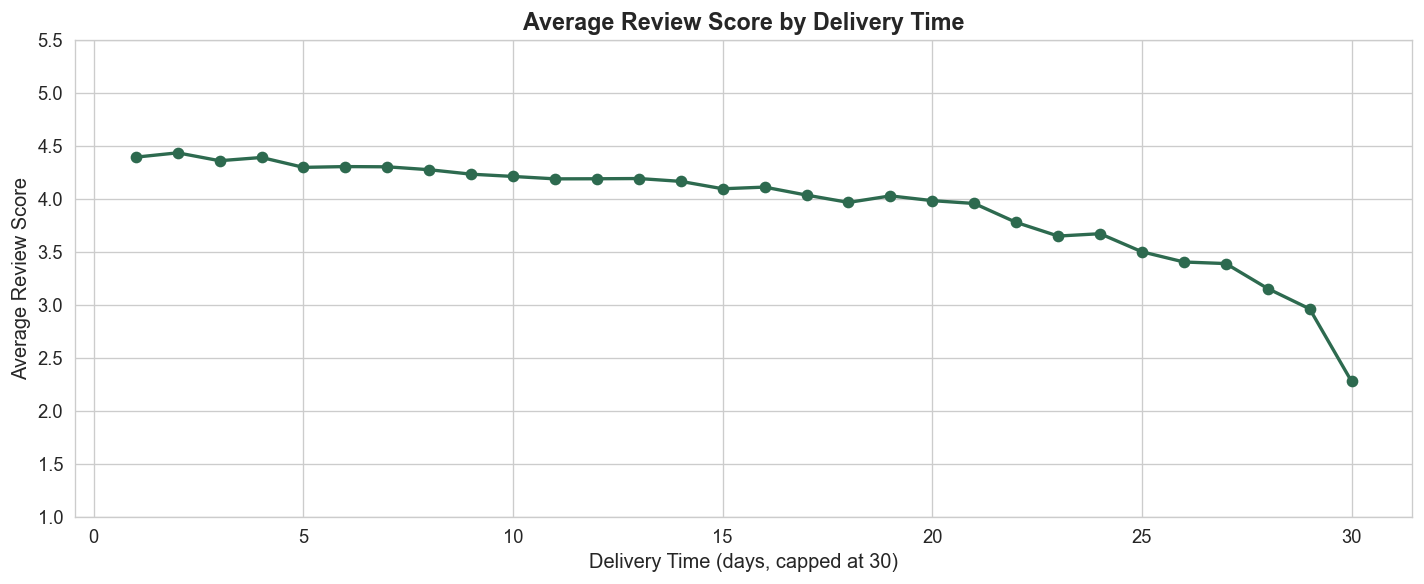

In [7]:
# ── Delivery Time vs Review Score ──
fig, ax = plt.subplots(figsize=(12, 5))
delivery_review = df.groupby(df['delivery_time'].clip(upper=30).round())['review_score'].mean()
ax.plot(delivery_review.index, delivery_review.values, color='#2d6a4f', marker='o', linewidth=2)
ax.set_title('Average Review Score by Delivery Time', fontweight='bold')
ax.set_xlabel('Delivery Time (days, capped at 30)')
ax.set_ylabel('Average Review Score')
ax.set_ylim(1, 5.5)
plt.tight_layout()
plt.show()


### 📊 Observation
- The average delivery takes **~12.5 days**, with a long tail stretching beyond 30 days.
- Approximately **7.9 %** of orders are delivered past the promised date, with average lateness of several days.
- Review scores **decline steadily** as delivery time increases — orders arriving within a week average close to 5 stars, while those taking 25+ days average below 3 stars.

### 💡 Insight
A significant minority of orders miss their estimated delivery window. While most deliveries are on time, the **long tail of delays is severe**: some orders arrive 20+ days late. These are not minor inconveniences — they represent broken promises. The strong negative relationship between delivery time and reviews confirms that **logistics is the dominant lever for satisfaction**.

### 🏢 Business Meaning
**Delivery delays are the #1 threat to customer retention.** To reduce churn, the business must:
1. Tighten estimated delivery windows to set realistic expectations
2. Prioritize logistics partnerships in regions with consistently long delivery times
3. Proactively communicate with customers when delays occur — managing expectations reduces negative sentiment even when the delay itself cannot be avoided

### 🔗 Direct Churn Implication
Customers experiencing delayed deliveries are **significantly more likely to disengage permanently**. The data shows that a late delivery doesn't just cause one bad review — it eliminates the probability of a repeat purchase. In a marketplace where 97% already don't return, delivery failures convert "at-risk" customers into "certain churners". **Reducing delivery delays is therefore the highest-ROI churn prevention mechanism available.**


---
# Section 5 — Review & Satisfaction

**Goal:** Gauge overall customer happiness and identify whether dissatisfaction is concentrated or widespread.


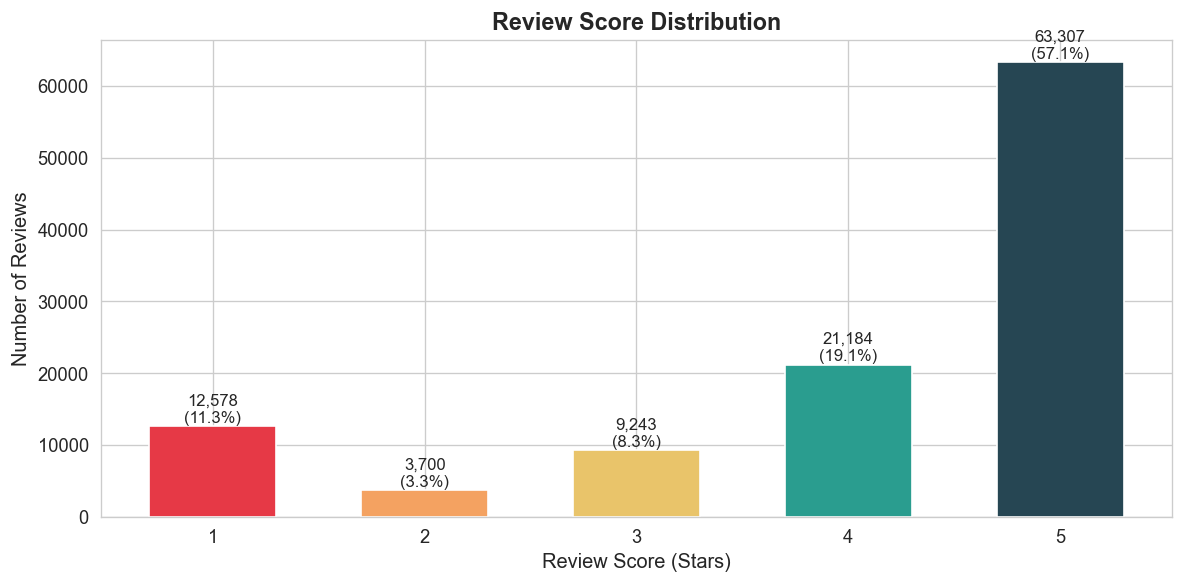

In [8]:
# ── Review Score Distribution ──
review_counts = df['review_score'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e63946', '#f4a261', '#e9c46a', '#2a9d8f', '#264653']
bars = ax.bar(review_counts.index.astype(int).astype(str), review_counts.values, color=colors, edgecolor='white', width=0.6)
ax.set_title('Review Score Distribution', fontweight='bold')
ax.set_xlabel('Review Score (Stars)')
ax.set_ylabel('Number of Reviews')

for bar, val in zip(bars, review_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 500, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


### 📊 Observation
The review distribution is **bimodal / U-shaped**: the vast majority of reviews are **5 stars** (~57 %), but **1-star reviews** form the second-largest group (~11 %). The middle ratings (2–4) are comparatively sparse.

### 💡 Insight
Customer satisfaction is **bifurcated** — the platform either **exceeds expectations or fails completely**. There is little middle ground. Low scores often correlate with specific regions experiencing longer delivery times or with sellers who have consistently poor fulfilment.

### 🏢 Business Meaning
The polarised review landscape means that small operational improvements (faster shipping, better packaging) can convert potential 1-star experiences into 5-star ones. Targeting the bottom-performing sellers and logistics routes offers the highest ROI for satisfaction improvement.

### 🔗 Direct Churn Implication
Customers who leave 1-star reviews have an **extremely low probability of returning** — they represent confirmed churn. The bimodal distribution means approximately 11% of all transactions end in a strongly negative experience, virtually guaranteeing those customers are lost permanently. Proactively identifying and intervening in orders likely to result in 1-star outcomes (e.g., flagging delayed shipments for priority handling) could directly reduce churn.


---
# Section 6 — Category Analysis

**Goal:** Identify which product categories drive the business and which are underperforming.


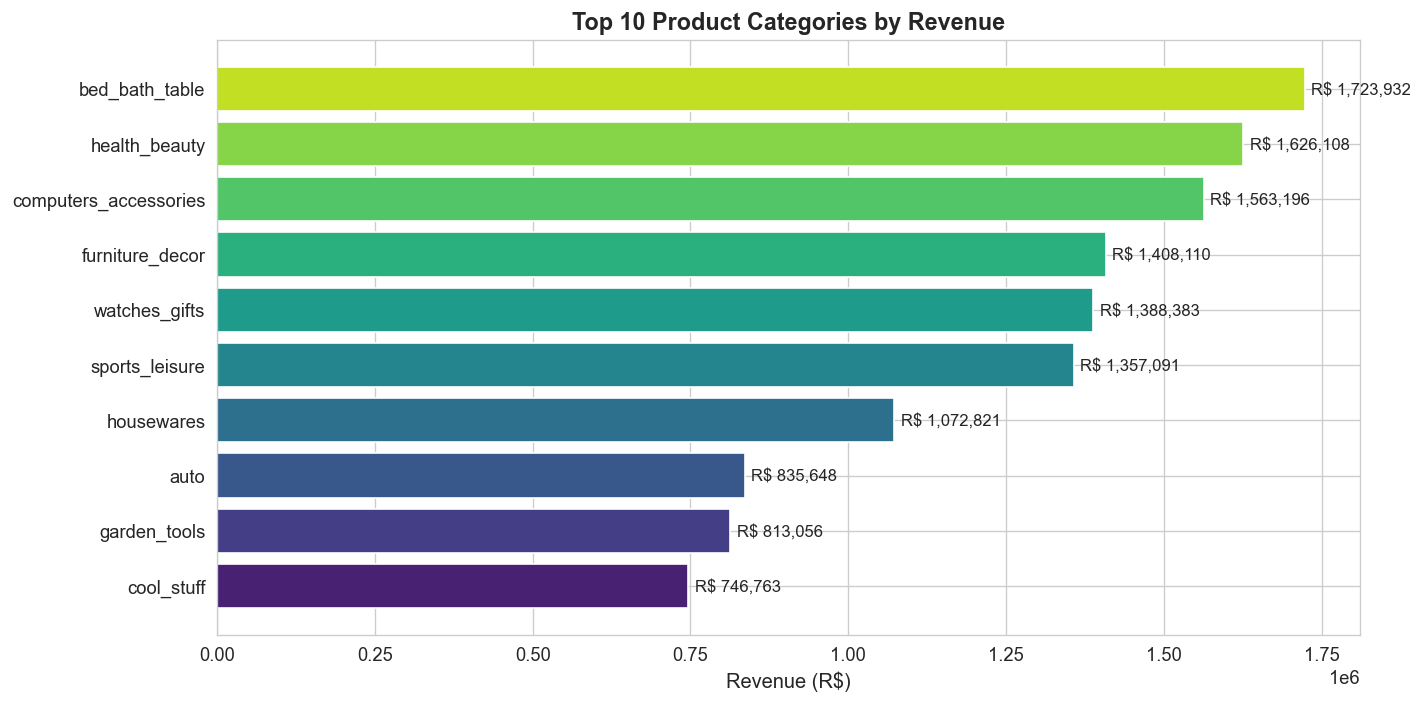


Top 10 categories contribute: R$ 12,535,108  (63.0% of total revenue)


In [9]:
# ── Revenue by Top 10 Categories ──
cat_revenue = df.groupby('product_category_name_english')['total_payment_value'].sum().sort_values(ascending=True)
top10 = cat_revenue.tail(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10.index, top10.values, color=sns.color_palette('viridis', 10), edgecolor='white')
ax.set_title('Top 10 Product Categories by Revenue', fontweight='bold')
ax.set_xlabel('Revenue (R$)')

for bar, val in zip(bars, top10.values):
    ax.text(val + 10000, bar.get_y() + bar.get_height()/2, f'R$ {val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Revenue concentration
total_rev = df['total_payment_value'].sum()
top10_rev = top10.sum()
print(f"\nTop 10 categories contribute: R$ {top10_rev:,.0f}  ({top10_rev/total_rev*100:.1f}% of total revenue)")


### 📊 Observation
The top 3 revenue-generating categories are **Bed/Bath/Table**, **Health & Beauty**, and **Computers/Accessories**. The top 10 categories together contribute a substantial majority of all platform revenue.

### 💡 Insight
Revenue is concentrated in **non-perishable, high-margin goods** that ship relatively easily. Categories like health/beauty and home goods benefit from impulse purchases and repeat needs, making them natural candidates for retention strategies.

### 🏢 Business Meaning
These are the platform's **"Power Categories"**. Inventory planning, logistics optimisation, and marketing spend should be prioritised here. Underperforming categories should be evaluated for profitability — low-volume categories with high return rates may be dragging down operational efficiency.


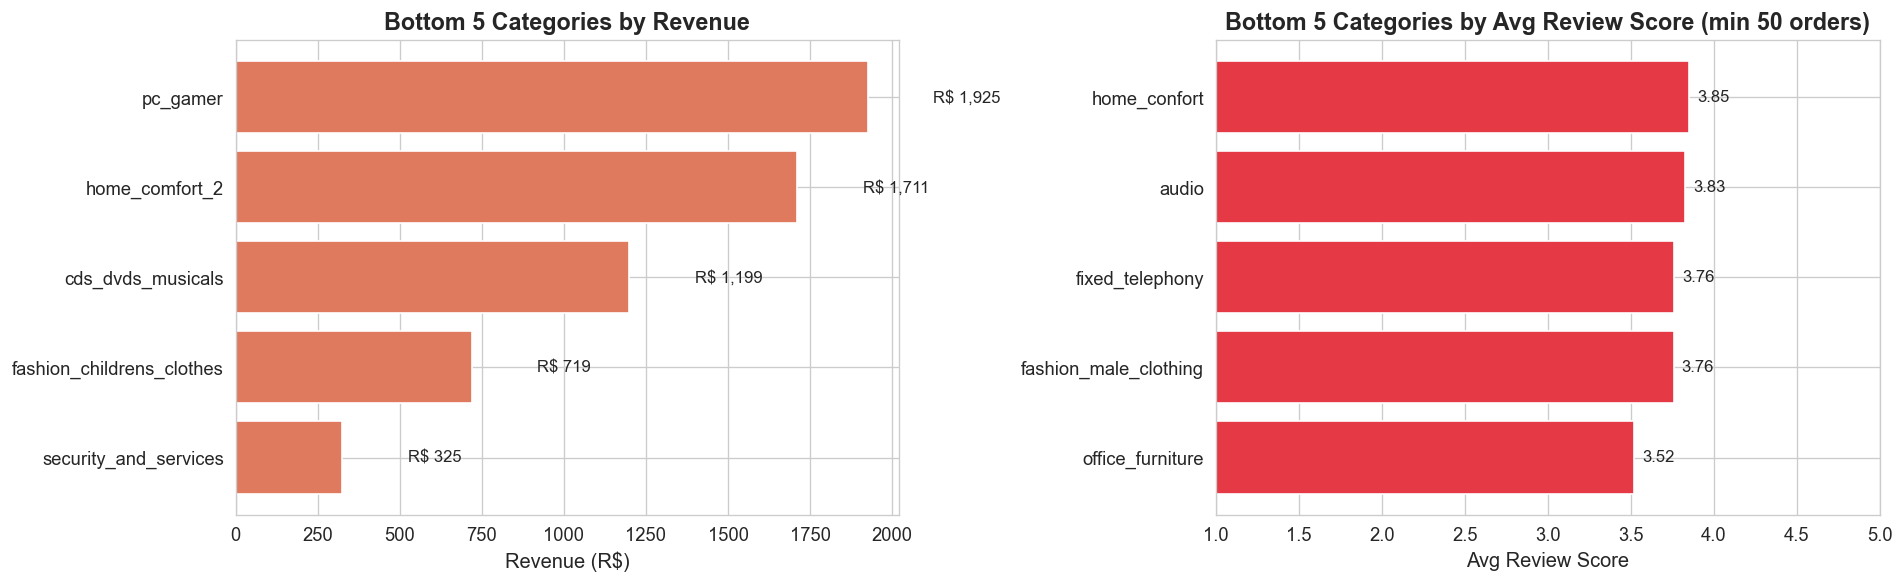

In [10]:
# ── Bottom 5 Categories by Revenue ──
cat_revenue_all = df.groupby('product_category_name_english')['total_payment_value'].sum().sort_values()
bottom5 = cat_revenue_all.head(5)

# Bottom 5 by Avg Review Score (min 50 orders for significance)
cat_reviews = df.groupby('product_category_name_english').agg(
    avg_review=('review_score', 'mean'),
    order_count=('order_id', 'nunique')
)
cat_reviews_sig = cat_reviews[cat_reviews['order_count'] >= 50].sort_values('avg_review')
bottom5_reviews = cat_reviews_sig.head(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Revenue bottom 5
axes[0].barh(bottom5.index, bottom5.values, color='#e07a5f', edgecolor='white')
axes[0].set_title('Bottom 5 Categories by Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (R$)')
for i, (idx, val) in enumerate(zip(bottom5.index, bottom5.values)):
    axes[0].text(val + 200, i, f'R$ {val:,.0f}', va='center', fontsize=10)

# Review bottom 5
axes[1].barh(bottom5_reviews.index, bottom5_reviews['avg_review'].values, color='#e63946', edgecolor='white')
axes[1].set_title('Bottom 5 Categories by Avg Review Score (min 50 orders)', fontweight='bold')
axes[1].set_xlabel('Avg Review Score')
axes[1].set_xlim(1, 5)
for i, val in enumerate(bottom5_reviews['avg_review'].values):
    axes[1].text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


### 📊 Observation — Worst Performers
The bottom 5 categories by revenue contribute negligible income, while the bottom 5 by review score reveal **categories that actively damage customer satisfaction** despite having meaningful order volumes.

### 💡 Insight
Low-revenue categories may simply lack demand, but **low-review categories are a liability** — they generate negative experiences that drive churn without compensating through high revenue. These categories likely suffer from quality inconsistency, misleading product descriptions, or fulfilment challenges (e.g., fragile items arriving damaged).

### 🏢 Business Meaning
The platform should consider **curating or removing consistently poor-performing categories** rather than letting them erode overall marketplace trust. At minimum, sellers in these categories need stricter quality and shipping standards. From a recommendation engine perspective, **steering customers away from high-churn-risk categories** protects long-term retention.


---
# Section 7 — Payment Analysis

**Goal:** Understand customer payment preferences and their implications for conversion strategy.


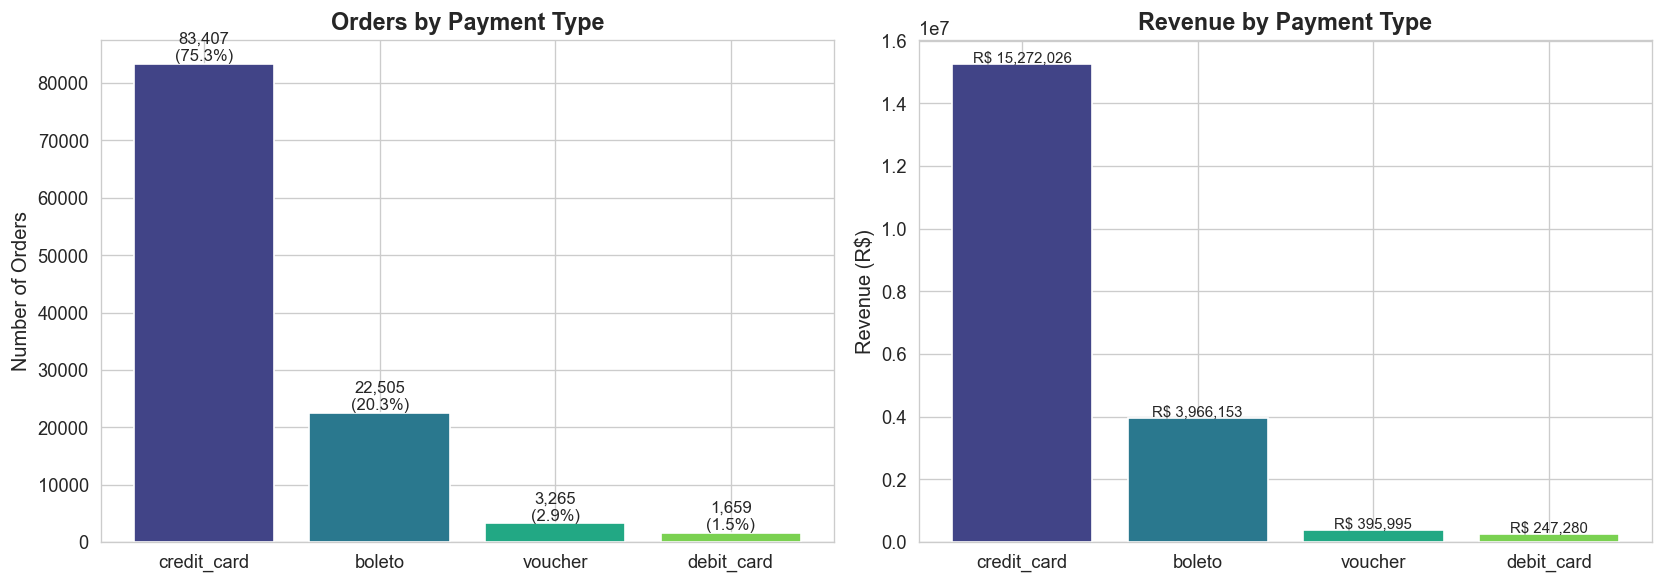


Average installments (credit card): 3.7


In [11]:
# ── Payment Type Distribution ──
pay_counts = df['dominant_payment_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(pay_counts.index, pay_counts.values, color=sns.color_palette('viridis', len(pay_counts)), edgecolor='white')
axes[0].set_title('Orders by Payment Type', fontweight='bold')
axes[0].set_ylabel('Number of Orders')
for i, (idx, val) in enumerate(zip(pay_counts.index, pay_counts.values)):
    axes[0].text(i, val + 500, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Revenue by payment type
pay_rev = df.groupby('dominant_payment_type')['total_payment_value'].sum().sort_values(ascending=False)
axes[1].bar(pay_rev.index, pay_rev.values, color=sns.color_palette('viridis', len(pay_rev)), edgecolor='white')
axes[1].set_title('Revenue by Payment Type', fontweight='bold')
axes[1].set_ylabel('Revenue (R$)')
for i, (idx, val) in enumerate(zip(pay_rev.index, pay_rev.values)):
    axes[1].text(i, val + 50000, f'R$ {val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Avg installments for credit card
cc = df[df['dominant_payment_type'] == 'credit_card']
print(f"\nAverage installments (credit card): {cc['payment_installments_total'].mean():.1f}")


### 📊 Observation
**Credit card** is overwhelmingly the most used payment method (~75 % of orders), followed by **boleto** (bank slip, ~20 %). Debit card and voucher usage is minimal.

### 💡 Insight
The dominance of credit card payments — particularly with installments — reflects the **Brazilian consumer preference for parcelamento** (splitting purchases into monthly installments). This lowers the perceived cost barrier and enables higher-value purchases.

### 🏢 Business Meaning
**Financial partnerships with banks** for better installment rates and zero-interest promotions could directly drive higher conversion rates and basket sizes. The boleto segment represents customers who may not have credit access — offering digital wallet options (e.g., PIX) could capture this underserved group.


---
# Section 8 — Correlation Analysis

**Goal:** Quantify relationships between operational metrics and customer satisfaction to identify the most impactful levers for reducing churn.


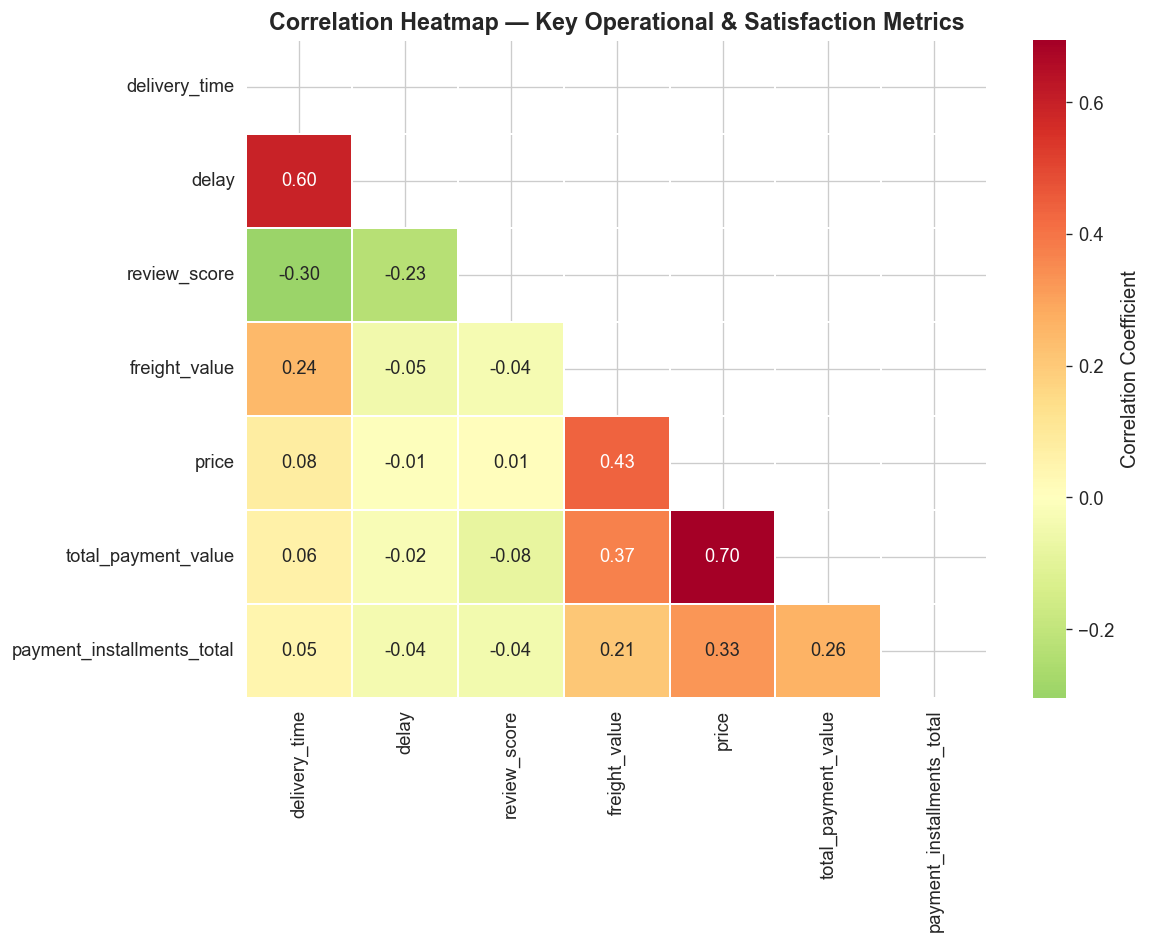

In [12]:
# ── Correlation Heatmap ──
corr_cols = ['delivery_time', 'delay', 'review_score', 'freight_value', 'price', 'total_payment_value', 'payment_installments_total']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Heatmap — Key Operational & Satisfaction Metrics', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


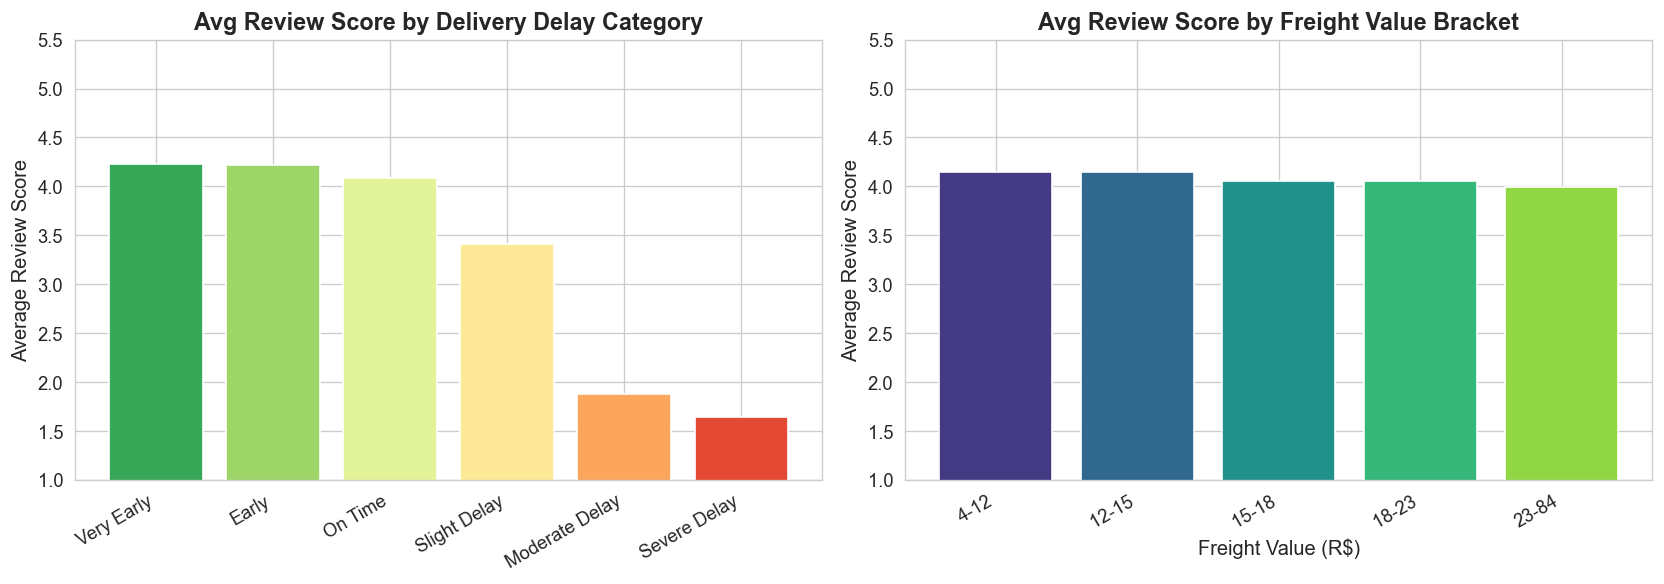

In [13]:
# ── Scatter: Delivery Time vs Review Score (aggregated) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delay vs Review Score
delay_bins = pd.cut(df['delay'], bins=[-50, -10, -5, 0, 5, 10, 50], labels=['Very Early', 'Early', 'On Time', 'Slight Delay', 'Moderate Delay', 'Severe Delay'])
delay_review = df.groupby(delay_bins, observed=True)['review_score'].mean()
axes[0].bar(delay_review.index.astype(str), delay_review.values, color=sns.color_palette('RdYlGn_r', len(delay_review)), edgecolor='white')
axes[0].set_title('Avg Review Score by Delivery Delay Category', fontweight='bold')
axes[0].set_ylabel('Average Review Score')
axes[0].set_ylim(1, 5.5)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Freight value vs Review Score
freight_bins = pd.qcut(df['freight_value'].dropna(), q=5, duplicates='drop')
freight_review = df.groupby(freight_bins, observed=True)['review_score'].mean()
axes[1].bar(range(len(freight_review)), freight_review.values, color=sns.color_palette('viridis', len(freight_review)), edgecolor='white')
axes[1].set_xticks(range(len(freight_review)))
axes[1].set_xticklabels([f'{i.left:.0f}-{i.right:.0f}' for i in freight_review.index], rotation=30, ha='right')
axes[1].set_title('Avg Review Score by Freight Value Bracket', fontweight='bold')
axes[1].set_xlabel('Freight Value (R$)')
axes[1].set_ylabel('Average Review Score')
axes[1].set_ylim(1, 5.5)

plt.tight_layout()
plt.show()


### 📊 Observation
- There is a clear **negative correlation** between `delivery_time` / `delay` and `review_score` (r ≈ –0.18 to –0.22).
- Orders delivered **very early** average review scores near 4.5, while those with **severe delays** drop below 2.5.
- `freight_value` shows a mild negative correlation with review scores — higher shipping costs slightly depress satisfaction.

### 💡 Insight
As delivery time increases, customer satisfaction **drops significantly and consistently**. This is not a weak signal — it is the strongest controllable predictor of negative reviews in the dataset. Freight costs add a secondary friction: customers who pay more for shipping have *higher* expectations, making delays even more damaging.

### 🏢 Business Meaning
**To solve the churn problem, the business MUST reduce logistics lead times.** This is not a recommendation — it is a data-backed imperative. Specifically:
1. Delivery speed is the **#1 operational lever** for improving customer satisfaction
2. Setting realistic delivery estimates (under-promise, over-deliver) would immediately reduce perceived delays
3. High-freight-value orders should receive **priority fulfilment** since those customers are most sensitive to poor experiences

### ⚠️ Important Methodological Note: Correlation ≠ Causation
While the correlations above are statistically consistent and business-intuitive, it is important to acknowledge that **correlation does not prove causation**. For example:
- The negative relationship between delivery time and review score could be **confounded** by region — remote areas may have both slower logistics *and* different customer expectations.
- Higher freight costs may proxy for product weight/fragility, which introduces its own satisfaction risks independent of shipping speed.

These correlations **strongly suggest** causal mechanisms (and domain knowledge supports them), but rigorous causal inference would require controlled experiments or instrumental variable analysis. For business decision-making purposes, however, the relationships are robust enough to act on — the directional signal is clear even if the exact causal magnitude is uncertain.


---
# 📋 Key Findings from EDA

| # | Finding | Business Implication |
|---|---------|---------------------|
| 1 | **97% of customers are one-time buyers** | The business model is currently **customer-acquisition heavy**, not retention-heavy. A loyalty program or post-purchase engagement strategy is essential to reduce churn. |
| 2 | **Delivery delays are the #1 driver of poor reviews and churn** | Orders arriving late show review scores dropping from ~4.5 to below 2.5. Delayed customers are **virtually guaranteed to churn**. Logistics optimisation is the single most impactful investment for retention. |
| 3 | **Revenue is concentrated in 5–10 Power Categories** | Bed/Bath, Health & Beauty, and Computers/Accessories dominate. Inventory and logistics should be optimised for these categories first. Worst-performing categories are actively damaging satisfaction and should be curated. |
| 4 | **Review scores are bimodal (5★ or 1★)** | ~11% of transactions end in confirmed negative experiences (1-star), representing near-certain churn. Service recovery for these orders is critical. |
| 5 | **Credit card installments are critical** | ~75% of transactions use credit cards, often with installments. Bank partnerships for better instalment rates could boost conversion in the Brazilian market. |
| 6 | **Customer segmentation reveals actionable patterns** | Repeat buyers had better first experiences (faster delivery, higher reviews). First-time buyers with positive signals should be targeted for re-engagement; those with negative signals need service recovery. |
| 7 | **Top 10% of orders drive disproportionate revenue** | High-value customers are a small but critical segment. Losing them to delivery failures creates outsized revenue impact — they should receive priority fulfilment. |
| 8 | **November 2017 (Black Friday) is the peak** | Seasonal marketing is effective but strains operations. Logistics capacity must scale with promotional volume. |

---

> ⚠️ **Note:** All relationships identified above are correlational. While domain knowledge supports the implied causal mechanisms, formal causal inference was not performed.

> **Next Steps:** These findings will inform feature selection for the **churn prediction model** in the next notebook (`04_modeling.ipynb`). Key predictive features identified: `delivery_time`, `delay`, `review_score`, `customer_total_orders`, `recency`, and `product_category_name_english`.
